# Random Forest + Neural Network Classifier
### Spheroid Viability Prediction from Morphological Features
---
**Pipeline overview**
1. Load & clean data  
2. Feature extraction → engineering → selection (top 30, mutual information)  
3. 5-Fold stratified cross-validation — Random Forest  
4. Final RF model with SMOTE balancing  
5. Neural Network training & K-fold evaluation  
6. Comprehensive metric visualisations (confusion matrices, ROC, box plots)  
7. Temperature vs. predicted-label plots with logistic regression & IC50  
8. Per-feature temperature scatter plots  
9. Violin plots & CSV export of OOF predictions  


## 0. Imports

In [43]:
import sys
!{sys.executable} -m pip install -U imbalanced-learn


In [44]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score,
)
from imblearn.over_sampling import SMOTE
import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
print("All imports OK")
print(f"TensorFlow version: {tf.__version__}")


All imports OK
TensorFlow version: 2.20.0


## 1. Configuration
Edit `INPUT_CSV` to point at your data file. All outputs will be saved alongside it.

In [45]:
INPUT_CSV  = r'F:\Experiments\PTT\Spheroids\all data\mcf7\combined_immediate_days.csv'
OUTPUT_DIR = Path(INPUT_CSV).parent
print(f"Input : {INPUT_CSV}")
print(f"Output: {OUTPUT_DIR}")


Input : F:\Experiments\PTT\Spheroids\all data\mcf7\combined_immediate_days.csv
Output: F:\Experiments\PTT\Spheroids\all data\mcf7


## 2. Load & Prepare Data

In [46]:
# Configuration: Choose the days for features (list of 0, 1, or 2)
SELECTED_DAYS = [2]  # Change this to [0], [1], [2], [0,1], [1,2], etc. to select features from those days
print(f"Selected days for features: {[f'day{day}' for day in SELECTED_DAYS]}")

Selected days for features: ['day2']


In [47]:
df = pd.read_csv(INPUT_CSV, sep=',', index_col=0)
df_complete = df[df['Label_day2'].notna()].copy()
#df_complete=df_complete.dropna(axis=0, how='any')
print(f"Total samples : {len(df_complete)}")
print(f"  Alive        : {(df_complete['Label_day2'] == 'Alive').sum()}")
print(f"  Dead         : {(df_complete['Label_day2'] == 'Dead').sum()}")
print(df.shape)



Total samples : 302
  Alive        : 226
  Dead         : 76
(583, 64)


## 3. Feature Extraction
Keep only morphological / texture columns measured at day 0, 1, 2, or delta.
Temperature is intentionally excluded from training features.

In [48]:
include_patterns = [
    'Area (pix2)', 'Circularity', 'Solidity', 'Perimeter (pix)', 'Aspect ratio',
    'Mean grey value', 'Energy', 'Homogeneity', 'Correlation', 'Equivalent Diameter (pix)','Area (um2)','Perimeter (um)','Equivalent Diameter (um)'
]

numerical_features = [
    col for col in df_complete.columns
    if any(p in col for p in include_patterns)
    #and any(d in col for d in ['_day0', '_day1', '_day2', '_delta'])
    and any(d in col for d in [ f'_day{SELECTED_DAY}' for SELECTED_DAY in SELECTED_DAYS ] + [f'_delta{day}' for day in SELECTED_DAYS if day != 0] )
    #and df_complete[col].dtype in ['float64', 'int64', 'float32', 'int32']
]

X_features = df_complete[numerical_features].copy()

# Impute missing values with column median
'''for col in X_features.columns:
    if X_features[col].isna().any():
        X_features[col] = X_features[col].fillna(X_features[col].median())'''

X_features = X_features.dropna(axis=0, how='any')


# Define y HERE while index is still aligned
y = (df_complete.loc[X_features.index, 'Label_day2'] == 'Alive').astype(int).reset_index(drop=True)
# Save positional indices in df_complete that survived dropna
df_complete_positions = np.array([df_complete.index.get_loc(idx) for idx in X_features.index])

# Now safe to reset
X_features = X_features.reset_index(drop=True)

print(f"Samples after dropna: {X_features.shape[0]}")
print(f"y length: {len(y)}")  # should match


print(f"Base features extracted: {len(numerical_features)}")
print(numerical_features)
print(f"After dropna: {X_features.shape[0]} samples")


Samples after dropna: 0
y length: 0
Base features extracted: 11
['Area (um2)_day2', 'Perimeter (pix)_day2', 'Solidity_day2', 'Equivalent Diameter (pix)_day2', 'Circularity_day2', 'Aspect ratio_day2', 'Mean grey value_day2', 'Homogeneity_day2', 'Energy_day2', 'Correlation_day2', 'Area (pix2)_day2']
After dropna: 0 samples


## 4. Feature Engineering
Compute growth rates, grey-value deltas, morphological compactness,
and interaction terms.

In [49]:
area_day0  = [c for c in X_features.columns if 'Area (um2)' in c and 'day0' in c]
area_day1  = [c for c in X_features.columns if 'Area (um2)' in c and 'day1' in c]
area_day2  = [c for c in X_features.columns if 'Area (um2)' in c and 'day2' in c]
grey_day0  = [c for c in X_features.columns if 'Mean grey value' in c and 'day0' in c]
grey_day1  = [c for c in X_features.columns if 'Mean grey value' in c and 'day1' in c]
grey_day2  = [c for c in X_features.columns if 'Mean grey value' in c and 'day2' in c]
homog_day2 = [c for c in X_features.columns if 'Homogeneity' in c and 'day2' in c]
perim_day2 = [c for c in X_features.columns if 'Perimeter (um)' in c and 'day2' in c]

if area_day0 and area_day2:
    X_features['area_growth_0to2'] = (
        (X_features[area_day2[0]] - X_features[area_day0[0]])
    )
    print("✓ area_growth_0to2")

if area_day1 and area_day2:
    X_features['area_growth_1to2'] = (
        (X_features[area_day2[0]] - X_features[area_day1[0]])
    )
    print("✓ area_growth_1to2")

if grey_day0 and grey_day2:
    X_features['grey_change_0to2'] = X_features[grey_day2[0]] - X_features[grey_day0[0]]
    X_features['grey_ratio_0to2']  = X_features[grey_day2[0]] / (X_features[grey_day0[0]])
    print("✓ grey_change_0to2, grey_ratio_0to2")

if grey_day1 and grey_day2:
    X_features['grey_change_1to2'] = X_features[grey_day2[0]] - X_features[grey_day1[0]]
    print("✓ grey_change_1to2")

if area_day2 and perim_day2:
    X_features['compactness_day2'] = (
        (4 * np.pi * X_features[area_day2[0]]) / (X_features[perim_day2[0]] ** 2 + 1)
    )
    print("✓ compactness_day2")

if homog_day2 and area_day2:
    X_features['homog_area_day2'] = X_features[homog_day2[0]] * X_features[area_day2[0]]
    print("✓ homog_area_day2")

if 'grey_change_0to2' in X_features.columns and 'area_growth_0to2' in X_features.columns:
    X_features['grey_area_interaction'] = (
        X_features['grey_change_0to2'] * X_features['area_growth_0to2']
    )
    print("✓ grey_area_interaction")

print(f"\nTotal features after engineering: {X_features.shape[1]}")


✓ homog_area_day2

Total features after engineering: 12


## 5. Feature Selection — Top 30 (Mutual Information)

In [50]:
use_feature_selection = True  # Set to True to enable feature selection with SelectKBest

print(y)
if use_feature_selection:
    selector = SelectKBest(mutual_info_classif, k=30)
    X_selected = selector.fit_transform(X_features, y)
    selected_feature_names = X_features.columns[selector.get_support()].tolist()
else:
    X_selected = X_features.values
    selected_feature_names = X_features.columns.tolist()
    display(X_features)

print(f"Using {X_selected.shape[1]} features")

if use_feature_selection:
    print("\nTop 10 selected features:")
    for i, name in enumerate(selected_feature_names[:10], 1):
        print(f"  {i:2d}. {name}")
else:
    print("Feature selection disabled, using all features.")


Series([], Name: Label_day2, dtype: int64)


ValueError: Found array with 0 sample(s) (shape=(0, 12)) while a minimum of 1 is required by SelectKBest.

## 6. Random Forest — 5-Fold Stratified Cross-Validation

In [ ]:
n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"X_selected shape: {X_selected.shape}")
print(f"y shape: {len(y)}")

fold_accuracies, fold_precisions, fold_recalls = [], [], []
fold_f1_scores, fold_auc_scores = [], []

all_y_true, all_y_pred, all_y_proba, all_fold_indices = [], [], [], []
confusion_matrices = []

fold_val_indices, fold_val_predictions, fold_val_probas = [], [], []

rf_oof_pred  = np.full(len(df_complete), np.nan)
rf_oof_proba = np.full(len(df_complete), np.nan)

print(f"{'Fold':>5} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>6} | {'F1':>8} | {'AUC':>7}")
print("-" * 55)

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_selected, y), 1):
    X_tr, X_vl = X_selected[train_idx], X_selected[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_vl_s = scaler.transform(X_vl)

    rf = RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1,
    )
    rf.fit(X_tr_s, y_tr)

    y_pred  = rf.predict(X_vl_s)
    y_proba = rf.predict_proba(X_vl_s)[:, 1]

    acc  = accuracy_score(y_vl, y_pred)
    prec = precision_score(y_vl, y_pred)
    rec  = recall_score(y_vl, y_pred)
    f1   = f1_score(y_vl, y_pred)
    auc_ = roc_auc_score(y_vl, y_proba)

    fold_accuracies.append(acc);  fold_precisions.append(prec)
    fold_recalls.append(rec);     fold_f1_scores.append(f1)
    fold_auc_scores.append(auc_); confusion_matrices.append(confusion_matrix(y_vl, y_pred))

    all_y_true.extend(y_vl);       all_y_pred.extend(y_pred)
    all_y_proba.extend(y_proba);   all_fold_indices.extend([fold_idx] * len(y_vl))

    fold_val_indices.append(val_idx)
    fold_val_predictions.append(y_pred)
    fold_val_probas.append(y_proba)

    rf_oof_pred[val_idx]  = y_pred
    rf_oof_proba[val_idx] = y_proba

    print(f"{fold_idx:>5} | {acc:>8.4f} | {prec:>9.4f} | {rec:>6.4f} | {f1:>8.4f} | {auc_:>7.4f}")


X_selected shape: (302, 37)
y shape: 23794
 Fold | Accuracy | Precision | Recall |       F1 |     AUC
-------------------------------------------------------


ValueError: Found input variables with inconsistent numbers of samples: [302, 23794]

## 7. Aggregate Cross-Validation Results

In [ ]:
all_y_true  = np.array(all_y_true)
all_y_pred  = np.array(all_y_pred)
all_y_proba = np.array(all_y_proba)
overall_cm  = confusion_matrix(all_y_true, all_y_pred)

print(f"Mean Accuracy  : {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Mean Precision : {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"Mean Recall    : {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"Mean F1-Score  : {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")
print(f"Mean AUC       : {np.mean(fold_auc_scores):.4f} ± {np.std(fold_auc_scores):.4f}")
print(f"\nOverall Confusion Matrix (all folds combined):")
print(f"               Pred: Dead  Alive")
print(f"  True: Dead      {overall_cm[0,0]:4d}   {overall_cm[0,1]:4d}")
print(f"  True: Alive     {overall_cm[1,0]:4d}   {overall_cm[1,1]:4d}")


Mean Accuracy  : 0.7850 ± 0.0588
Mean Precision : 0.5865 ± 0.1377
Mean Recall    : 0.5000 ± 0.0782
Mean F1-Score  : 0.5239 ± 0.0593
Mean AUC       : 0.8671 ± 0.0626

Overall Confusion Matrix (all folds combined):
               Pred: Dead  Alive
  True: Dead       202     30
  True: Alive       35     35


## 8. Final RF Model — Train / Test Split with SMOTE
25 % held-out test set; training set balanced with SMOTE before fitting.

In [ ]:
_all_indices = np.arange(len(df_complete))
X_train_final, X_test_final, y_train_final, y_test_final, _train_pos, _test_pos = train_test_split(
    X_selected, y, _all_indices, test_size=0.25, random_state=42, stratify=y,
)

scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled  = scaler_final.transform(X_test_final)

print("Class distribution before SMOTE:", Counter(y_train_final))
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final_scaled, y_train_final)
print("Class distribution after  SMOTE:", Counter(y_train_balanced))

rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
rf_final.fit(X_train_balanced, y_train_balanced)

y_pred_final  = rf_final.predict(X_test_final_scaled)
y_proba_final = rf_final.predict_proba(X_test_final_scaled)[:, 1]

final_acc  = accuracy_score(y_test_final, y_pred_final)
final_prec = precision_score(y_test_final, y_pred_final)
final_rec  = recall_score(y_test_final, y_pred_final)
final_f1   = f1_score(y_test_final, y_pred_final)
final_auc  = roc_auc_score(y_test_final, y_proba_final)

print(f"\n{'Metric':<12} {'Score':>8}")
print("-" * 22)
for name, val in [('Accuracy', final_acc), ('Precision', final_prec),
                  ('Recall', final_rec), ('F1-Score', final_f1), ('AUC', final_auc)]:
    print(f"{name:<12} {val:>8.4f}")


Class distribution before SMOTE: Counter({0: 174, 1: 52})
Class distribution after  SMOTE: Counter({1: 174, 0: 174})

Metric          Score
----------------------
Accuracy       0.7632
Precision      0.5000
Recall         0.5000
F1-Score       0.5000
AUC            0.8372


## 9. RF — Comprehensive Performance Dashboard

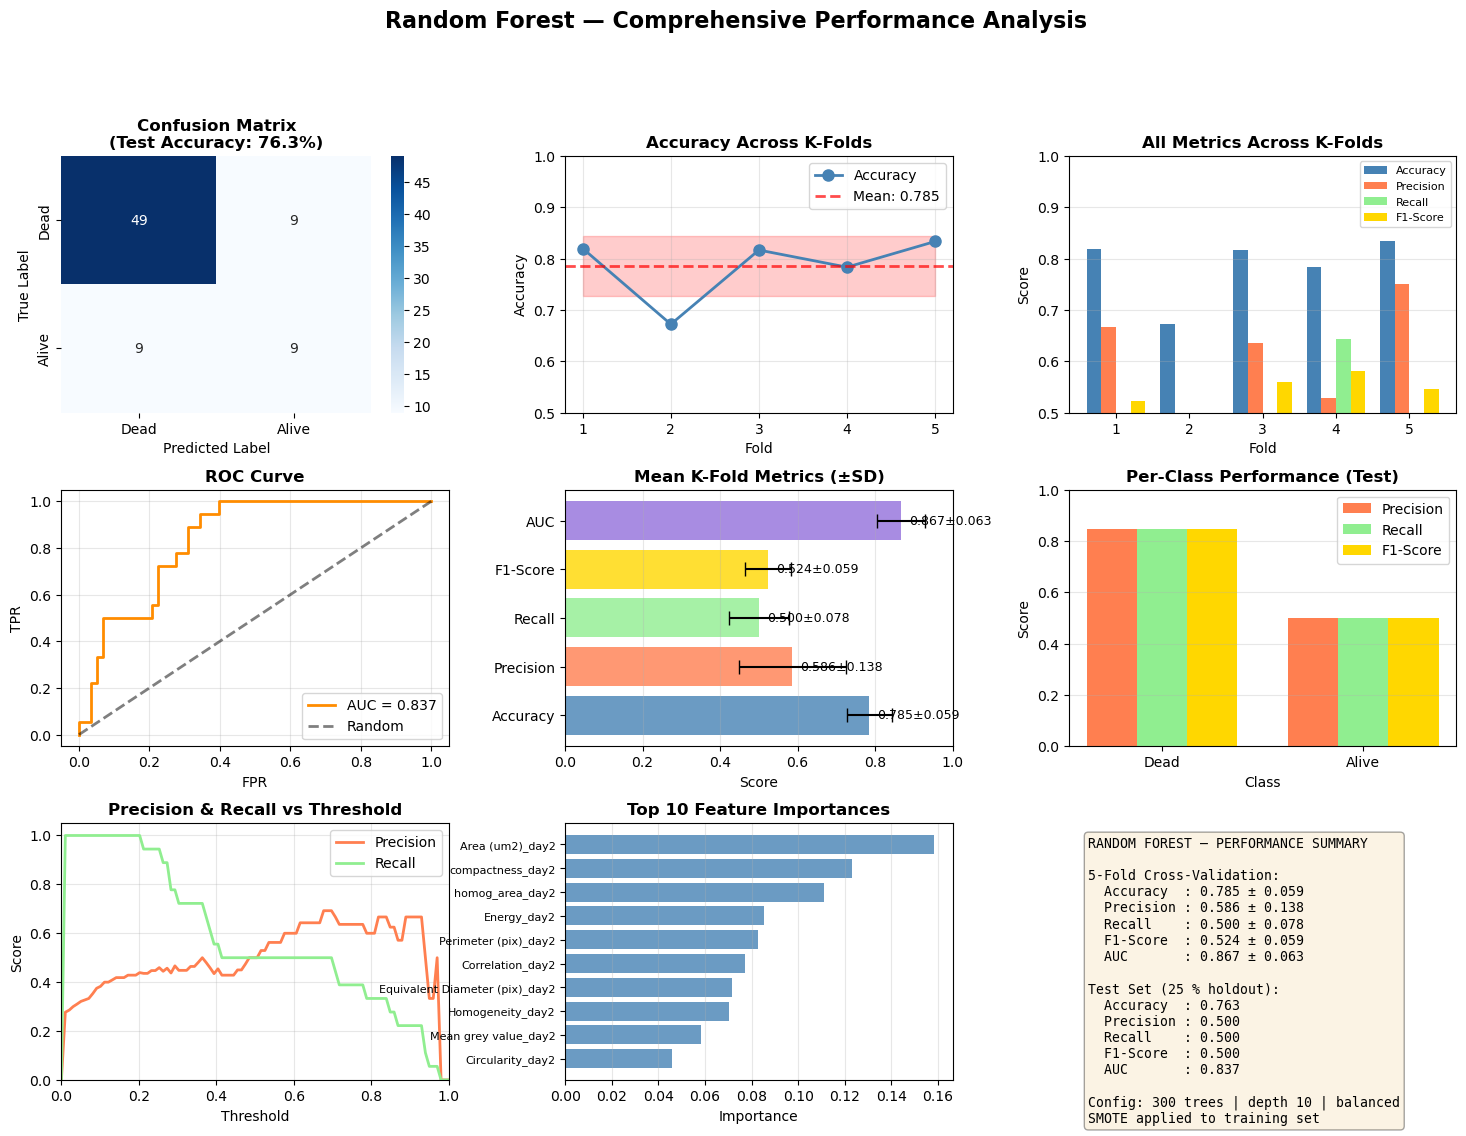

Saved → F:\Experiments\PTT\Spheroids\all data\mcf7\rf_complete_analysis.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm_final = confusion_matrix(y_test_final, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax1.set_title(f'Confusion Matrix\n(Test Accuracy: {final_acc*100:.1f}%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=10); ax1.set_xlabel('Predicted Label', fontsize=10)

# 2. Per-Fold Accuracy
ax2  = fig.add_subplot(gs[0, 1])
folds = np.arange(1, n_splits + 1)
ax2.plot(folds, fold_accuracies, marker='o', linewidth=2, markersize=8, color='steelblue', label='Accuracy')
ax2.axhline(np.mean(fold_accuracies), color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Mean: {np.mean(fold_accuracies):.3f}')
ax2.fill_between(folds,
                 np.mean(fold_accuracies) - np.std(fold_accuracies),
                 np.mean(fold_accuracies) + np.std(fold_accuracies),
                 alpha=0.2, color='red')
ax2.set_xlabel('Fold', fontsize=10); ax2.set_ylabel('Accuracy', fontsize=10)
ax2.set_title('Accuracy Across K-Folds', fontsize=12, fontweight='bold')
ax2.set_xticks(folds); ax2.grid(True, alpha=0.3); ax2.legend(); ax2.set_ylim([0.5, 1.0])

# 3. All Metrics per Fold
ax3   = fig.add_subplot(gs[0, 2])
x     = np.arange(n_splits)
width = 0.2
ax3.bar(x - 1.5*width, fold_accuracies,  width, label='Accuracy',  color='steelblue')
ax3.bar(x - 0.5*width, fold_precisions,  width, label='Precision', color='coral')
ax3.bar(x + 0.5*width, fold_recalls,     width, label='Recall',    color='lightgreen')
ax3.bar(x + 1.5*width, fold_f1_scores,   width, label='F1-Score',  color='gold')
ax3.set_xlabel('Fold', fontsize=10); ax3.set_ylabel('Score', fontsize=10)
ax3.set_title('All Metrics Across K-Folds', fontsize=12, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels([str(i+1) for i in range(n_splits)])
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y'); ax3.set_ylim([0.5, 1.0])

# 4. ROC Curve
ax4 = fig.add_subplot(gs[1, 0])
fpr_rf_test, tpr_rf_test, _ = roc_curve(y_test_final, y_proba_final)
ax4.plot(fpr_rf_test, tpr_rf_test, linewidth=2, label=f'AUC = {final_auc:.3f}', color='darkorange')
ax4.plot([0,1],[0,1], 'k--', linewidth=2, alpha=0.5, label='Random')
ax4.set_xlabel('FPR', fontsize=10); ax4.set_ylabel('TPR', fontsize=10)
ax4.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right'); ax4.grid(True, alpha=0.3)

# 5. Mean Metrics bar
ax5 = fig.add_subplot(gs[1, 1])
m_names = ['Accuracy','Precision','Recall','F1-Score','AUC']
m_vals  = [np.mean(fold_accuracies), np.mean(fold_precisions),
           np.mean(fold_recalls),    np.mean(fold_f1_scores),  np.mean(fold_auc_scores)]
m_stds  = [np.std(fold_accuracies),  np.std(fold_precisions),
           np.std(fold_recalls),     np.std(fold_f1_scores),   np.std(fold_auc_scores)]
c_bars  = ['steelblue','coral','lightgreen','gold','mediumpurple']
ax5.barh(m_names, m_vals, color=c_bars, alpha=0.8, xerr=m_stds, capsize=5)
ax5.set_xlabel('Score', fontsize=10); ax5.set_title('Mean K-Fold Metrics (±SD)', fontsize=12, fontweight='bold')
ax5.set_xlim([0, 1.0]); ax5.grid(True, alpha=0.3, axis='x')
for i, (v, s) in enumerate(zip(m_vals, m_stds)):
    ax5.text(v + 0.02, i, f'{v:.3f}±{s:.3f}', va='center', fontsize=9)

# 6. Per-Class Performance
ax6    = fig.add_subplot(gs[1, 2])
report = classification_report(y_test_final, y_pred_final,
                                target_names=['Dead','Alive'], output_dict=True)
x_pos  = np.arange(2); width = 0.25
ax6.bar(x_pos - width, [report['Dead']['precision'],  report['Alive']['precision']],  width, label='Precision', color='coral')
ax6.bar(x_pos,         [report['Dead']['recall'],     report['Alive']['recall']],     width, label='Recall',    color='lightgreen')
ax6.bar(x_pos + width, [report['Dead']['f1-score'],   report['Alive']['f1-score']],   width, label='F1-Score',  color='gold')
ax6.set_xlabel('Class', fontsize=10); ax6.set_ylabel('Score', fontsize=10)
ax6.set_title('Per-Class Performance (Test)', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos); ax6.set_xticklabels(['Dead','Alive'])
ax6.legend(); ax6.grid(True, alpha=0.3, axis='y'); ax6.set_ylim([0,1.0])

# 7. Precision–Recall vs Threshold
ax7 = fig.add_subplot(gs[2, 0])
prec_c, rec_c = [], []
for th in np.linspace(0, 1, 100):
    yp = (y_proba_final >= th).astype(int)
    if len(np.unique(yp)) > 1:
        prec_c.append(precision_score(y_test_final, yp))
        rec_c.append(recall_score(y_test_final, yp))
    else:
        prec_c.append(0); rec_c.append(0)
ax7.plot(np.linspace(0,1,100), prec_c, label='Precision', linewidth=2, color='coral')
ax7.plot(np.linspace(0,1,100), rec_c,  label='Recall',    linewidth=2, color='lightgreen')
ax7.set_xlabel('Threshold', fontsize=10); ax7.set_ylabel('Score', fontsize=10)
ax7.set_title('Precision & Recall vs Threshold', fontsize=12, fontweight='bold')
ax7.legend(); ax7.grid(True, alpha=0.3); ax7.set_xlim([0,1]); ax7.set_ylim([0,1.05])

# 8. Top-10 Feature Importances
ax8 = fig.add_subplot(gs[2, 1])
fi_df = pd.DataFrame({'feature': selected_feature_names,
                       'importance': rf_final.feature_importances_}
                     ).sort_values('importance', ascending=False).head(10)
ax8.barh(range(len(fi_df)), fi_df['importance'], color='steelblue', alpha=0.8)
ax8.set_yticks(range(len(fi_df))); ax8.set_yticklabels(fi_df['feature'], fontsize=8)
ax8.set_xlabel('Importance', fontsize=10); ax8.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
ax8.invert_yaxis(); ax8.grid(True, alpha=0.3, axis='x')

# 9. Text Summary
ax9 = fig.add_subplot(gs[2, 2]); ax9.axis('off')
summary = (
    f"RANDOM FOREST — PERFORMANCE SUMMARY\n\n"
    f"5-Fold Cross-Validation:\n"
    f"  Accuracy  : {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}\n"
    f"  Precision : {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}\n"
    f"  Recall    : {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}\n"
    f"  F1-Score  : {np.mean(fold_f1_scores):.3f} ± {np.std(fold_f1_scores):.3f}\n"
    f"  AUC       : {np.mean(fold_auc_scores):.3f} ± {np.std(fold_auc_scores):.3f}\n\n"
    f"Test Set (25 % holdout):\n"
    f"  Accuracy  : {final_acc:.3f}\n"
    f"  Precision : {final_prec:.3f}\n"
    f"  Recall    : {final_rec:.3f}\n"
    f"  F1-Score  : {final_f1:.3f}\n"
    f"  AUC       : {final_auc:.3f}\n\n"
    f"Config: 300 trees | depth 10 | balanced\nSMOTE applied to training set"
)
ax9.text(0.05, 0.95, summary, transform=ax9.transAxes, fontsize=9.5,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.35))

fig.suptitle('Random Forest — Comprehensive Performance Analysis',
             fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()
rf_dash_path = OUTPUT_DIR / 'rf_complete_analysis.png'
plt.savefig(rf_dash_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {rf_dash_path}")


## 10. Helper: Temperature vs Predicted Label
Reusable function that plots scatter + logistic regression curve + IC50
for any set of predictions against the maximum treatment temperature.

In [ ]:
def plot_temp_vs_predicted(temp_values, pred_labels=None, pred_proba=None,
                           title=None, ax=None, color='steelblue'):
    """
    Scatter of predicted labels / probabilities vs Max Temperature,
    with a logistic regression curve and IC50 annotation.

    Returns (fig, ax, ic50).
    """
    title = title or 'Predicted vs Max Temperature'
    standalone = ax is None
    if standalone:
        fig_out, ax = plt.subplots(figsize=(10, 6))
    else:
        fig_out = ax.get_figure()

    temp_arr  = np.array(temp_values, dtype=float)
    pred_arr  = np.array(pred_labels) if pred_labels  is not None else None
    proba_arr = np.array(pred_proba)  if pred_proba   is not None else None

    mask       = ~np.isnan(temp_arr)
    temp_clean = temp_arr[mask]
    pred_clean = pred_arr[mask]  if pred_arr  is not None else None
    proba_clean= proba_arr[mask] if proba_arr is not None else None

    if len(temp_clean) < 2:
        raise ValueError('Not enough temperature points.')

    # Decide fit source
    if pred_clean is not None and len(np.unique(pred_clean)) >= 2:
        fit_source = 'labels'
    elif proba_clean is not None and np.nanstd(proba_clean) > 1e-6:
        fit_source = 'proba'
    else:
        fit_source = 'none'

    # Scatter colour & y-values
    if pred_clean is not None:
        c_scatter   = ['#e74c3c' if p == 0 else '#2ecc71' for p in pred_clean]
        y_scatter   = pred_clean
        dead_count  = int((pred_clean == 0).sum())
        alive_count = int((pred_clean == 1).sum())
    else:
        c_scatter   = ['#e74c3c' if p < 0.5 else '#2ecc71' for p in proba_clean]
        y_scatter   = proba_clean
        dead_count  = int((proba_clean < 0.5).sum())
        alive_count = int((proba_clean >= 0.5).sum())

    # Logistic fit
    ic50      = None
    t_range   = np.linspace(temp_clean.min() - 1, temp_clean.max() + 1, 400)
    lr_proba  = None

    if fit_source == 'labels':
        lr = LogisticRegression(max_iter=1000)
        lr.fit(temp_clean.reshape(-1, 1), pred_clean)
        coef, intercept = lr.coef_[0][0], lr.intercept_[0]
        ic50     = -intercept / coef if abs(coef) > 1e-9 else None
        lr_proba = lr.predict_proba(t_range.reshape(-1, 1))[:, 1]
    elif fit_source == 'proba':
        y_clip  = np.clip(proba_clean, 1e-6, 1 - 1e-6)
        logit_y = np.log(y_clip / (1 - y_clip))
        A       = np.vstack([temp_clean, np.ones_like(temp_clean)]).T
        coeffs, *_ = np.linalg.lstsq(A, logit_y, rcond=None)
        coef, intercept = coeffs
        ic50     = -intercept / coef if abs(coef) > 1e-9 else None
        lr_proba = 1.0 / (1.0 + np.exp(-(coef * t_range + intercept)))
    else:
        print('Warning: cannot fit logistic regression (single class).')

    rng    = np.random.default_rng(42)
    jitter = rng.uniform(-0.025, 0.025, size=len(y_scatter))
    ax.scatter(temp_clean, y_scatter + jitter, c=c_scatter,
               alpha=0.7, edgecolors='black', linewidths=0.4, s=55, zorder=3)

    if lr_proba is not None:
        lbl = f'Logistic fit (IC50={ic50:.2f}°C)' if ic50 else 'Logistic fit'
        ax.plot(t_range, lr_proba, color=color, linewidth=2.5, label=lbl, zorder=4)

    ic50_str  = f'{ic50:.2f} °C' if ic50 else 'N/A'
    stats_txt = (f'n = {len(y_scatter)}   |   Dead = {dead_count}   Alive = {alive_count}\n'
                 f'IC50 = {ic50_str}')
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes, fontsize=10,
            va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    ax.set_title(title); ax.set_xlabel('Max Temperature (°C)')
    ax.set_ylabel('Predicted Label / Probability')
    ax.set_ylim(-0.2, 1.2); ax.legend(loc='lower right')

    if standalone:
        plt.tight_layout()
    return fig_out, ax, ic50


## 11. RF — Predicted Label vs Max Temperature
Best fold and final test-set predictions overlaid with a logistic regression
curve. The IC50 marks the temperature at which P(Alive) = 0.50.

Best fold: Fold 5  (Accuracy = 0.8333)


ValueError: Not enough temperature points.

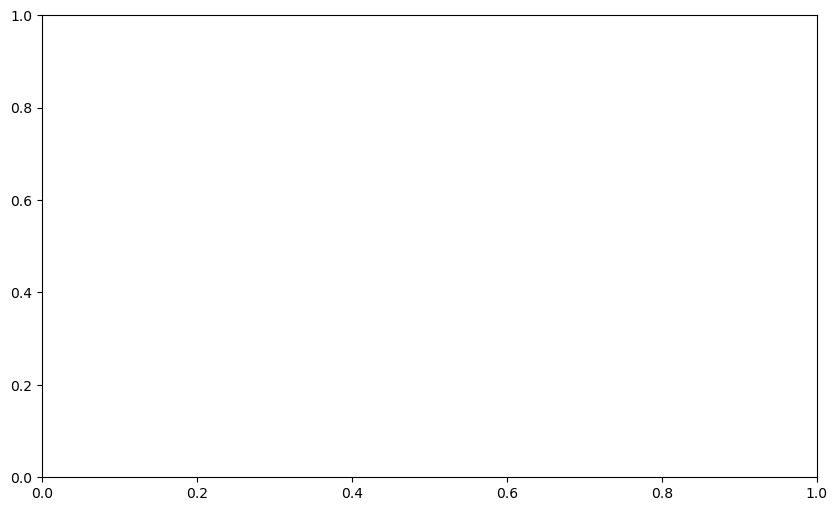

In [ ]:
best_fold_idx = int(np.argmax(fold_accuracies))
best_fold_num = best_fold_idx + 1
print(f"Best fold: Fold {best_fold_num}  (Accuracy = {fold_accuracies[best_fold_idx]:.4f})")

max_temp_col = next((c for c in df_complete.columns if 'Max temp' in c), None)

if max_temp_col is None:
    print("WARNING: 'Max temp' column not found — skipping temperature plots.")
else:
    # Best fold
    best_max_temp = df_complete.iloc[fold_val_indices[best_fold_idx]][max_temp_col].values.astype(float)
    fig_bf, _, ic50_bf = plot_temp_vs_predicted(
        best_max_temp,
        fold_val_predictions[best_fold_idx],
        pred_proba=fold_val_probas[best_fold_idx],
        title=f'RF Best Fold {best_fold_num} (Acc={fold_accuracies[best_fold_idx]*100:.1f}%) — Predicted Label vs Max Temperature',
        color='steelblue',
    )
    plt.show()
    print(f"Best-fold IC50 = {ic50_bf:.2f} °C" if ic50_bf else "IC50 outside data range")

    # Test set
    rf_test_max_temp = df_complete.iloc[_test_pos][max_temp_col].values.astype(float)
    fig_rf_t, _, ic50_rf = plot_temp_vs_predicted(
        rf_test_max_temp, y_pred_final, pred_proba=y_proba_final,
        title='Random Forest (Test Set) — Predicted Label vs Max Temperature',
        color='steelblue',
    )
    plt.show()
    print(f"Test-set IC50 = {ic50_rf:.2f} °C" if ic50_rf else "IC50 outside data range")


## 12. Neural Network — Training & Test Evaluation
Three-layer dense network: **128 → 10 → 2 (softmax)** trained with Adam / categorical cross-entropy.

In [ ]:
num_classes = 2
size        = X_train_final_scaled.shape[1]

y_train_nn = tf.keras.utils.to_categorical(y_train_final, num_classes)
y_test_nn  = tf.keras.utils.to_categorical(y_test_final,  num_classes)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(size,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10,  activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax'),
])
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train_final_scaled, y_train_nn,
    epochs=30, batch_size=32, validation_split=0.1, verbose=1,
)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_108 (Dense)               │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,976 (11.62 KB)

 Trainable params: 2,976 (11.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4861 - loss: 0.7175 - val_accuracy: 0.8125 - val_loss: 0.6375
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6944 - loss: 0.6722 - val_accuracy: 0.7500 - val_loss: 0.5941
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.6477 - val_accuracy: 0.7500 - val_loss: 0.5710
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7361 - loss: 0.6317 - val_accuracy: 0.7500 - val_loss: 0.5572
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7361 - loss: 0.6205 - val_accuracy: 0.8125 - val_loss: 0.5421
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7361 - loss: 0.6130 - val_accuracy: 0.8125 - val_loss: 0.5331
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7361 - loss: 0.6043 - val_accuracy: 0.7500 - val_loss: 0.5307
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7500 - loss: 0.5956 - val_accuracy: 0.7500 - val_loss: 0.5318
E

In [ ]:
nn_proba       = model.predict(X_test_final_scaled)
nn_pred        = np.argmax(nn_proba, axis=1)
nn_proba_alive = nn_proba[:, 1]

nn_acc  = accuracy_score(y_test_final, nn_pred)
nn_prec = precision_score(y_test_final, nn_pred)
nn_rec  = recall_score(y_test_final, nn_pred)
nn_f1   = f1_score(y_test_final, nn_pred)
nn_auc  = roc_auc_score(y_test_final, nn_proba_alive)

print(f"\n{'Metric':<12} {'RF':>8} {'NN':>8}")
print("-" * 30)
for name, rf_v, nn_v in [
    ('Accuracy',  final_acc,  nn_acc),
    ('Precision', final_prec, nn_prec),
    ('Recall',    final_rec,  nn_rec),
    ('F1-Score',  final_f1,   nn_f1),
    ('AUC',       final_auc,  nn_auc),
]:
    print(f"{name:<12} {rf_v:>8.4f} {nn_v:>8.4f}")
winner = 'RF' if final_acc > nn_acc else ('NN' if nn_acc > final_acc else 'Tie')
print(f"\nWinner by accuracy: {winner}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Metric             RF       NN
------------------------------
Accuracy       0.7222   0.7037
Precision      0.7805   0.7292
Recall         0.8421   0.9211
F1-Score       0.8101   0.8140
AUC            0.7023   0.6480

Winner by accuracy: RF


## 13. Neural Network — 5-Fold Cross-Validation (same splits as RF)

In [ ]:
nn_fold_accuracies, nn_fold_precisions = [], []
nn_fold_recalls,    nn_fold_f1_scores  = [], []
nn_fold_auc_scores                     = []

nn_oof_pred  = np.full(len(df_complete), np.nan)
nn_oof_proba = np.full(len(df_complete), np.nan)

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_selected, y), 1):
    X_tr, X_vl = X_selected[train_idx], X_selected[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_vl_s = sc.transform(X_vl)

    nn_fold_model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_tr_s.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10,  activation='relu'),
        tf.keras.layers.Dense(2,   activation='softmax'),
    ])
    nn_fold_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
    nn_fold_model.fit(
        X_tr_s, tf.keras.utils.to_categorical(y_tr, 2),
        epochs=30, batch_size=32, validation_split=0.1, verbose=0,
    )

    nn_proba_fold = nn_fold_model.predict(X_vl_s, verbose=0)
    nn_pred_fold  = np.argmax(nn_proba_fold, axis=1)
    nn_prob_alive = nn_proba_fold[:, 1]

    nn_fold_accuracies.append(accuracy_score(y_vl, nn_pred_fold))
    nn_fold_precisions.append(precision_score(y_vl, nn_pred_fold, zero_division=0))
    nn_fold_recalls.append(recall_score(y_vl, nn_pred_fold, zero_division=0))
    nn_fold_f1_scores.append(f1_score(y_vl, nn_pred_fold, zero_division=0))
    nn_fold_auc_scores.append(roc_auc_score(y_vl, nn_prob_alive))

    nn_oof_pred[val_idx]  = nn_pred_fold
    nn_oof_proba[val_idx] = nn_prob_alive

    print(f"  Fold {fold_idx}: Acc={nn_fold_accuracies[-1]:.4f}  "
          f"F1={nn_fold_f1_scores[-1]:.4f}  AUC={nn_fold_auc_scores[-1]:.4f}")

print(f"\nNN Mean Accuracy: {np.mean(nn_fold_accuracies):.4f} ± {np.std(nn_fold_accuracies):.4f}")


  Fold 1: Acc=0.6977  F1=0.8060  AUC=0.6821
  Fold 2: Acc=0.7442  F1=0.8308  AUC=0.6744
  Fold 3: Acc=0.7442  F1=0.8406  AUC=0.6897
  Fold 4: Acc=0.7209  F1=0.8235  AUC=0.5333
  Fold 5: Acc=0.7619  F1=0.8485  AUC=0.7306

NN Mean Accuracy: 0.7338 ± 0.0223


## 14. Neural Network — Comprehensive Performance Dashboard

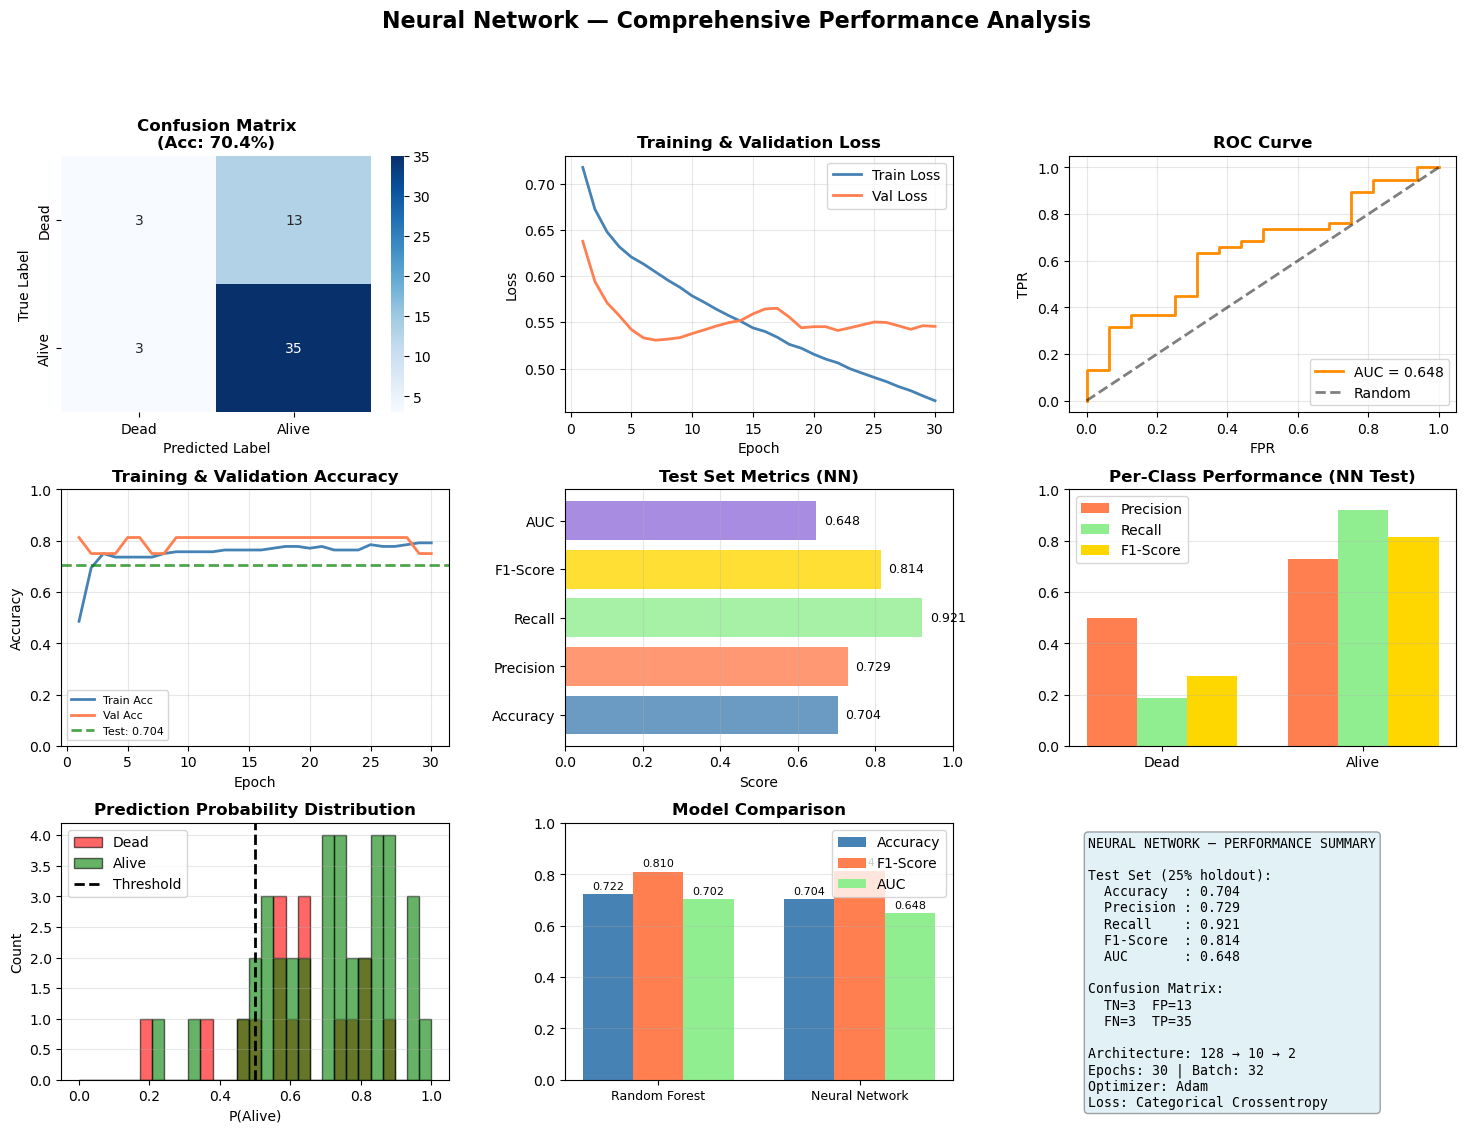

In [ ]:
fig_nn = plt.figure(figsize=(18, 12))
gs_nn  = fig_nn.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
epochs_range = np.arange(1, len(history.history['loss']) + 1)

# 1. Confusion Matrix
ax1n = fig_nn.add_subplot(gs_nn[0, 0])
cm_nn = confusion_matrix(y_test_final, nn_pred)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', ax=ax1n,
            xticklabels=['Dead','Alive'], yticklabels=['Dead','Alive'])
ax1n.set_title(f'Confusion Matrix\n(Acc: {nn_acc*100:.1f}%)', fontsize=12, fontweight='bold')
ax1n.set_ylabel('True Label', fontsize=10); ax1n.set_xlabel('Predicted Label', fontsize=10)

# 2. Training Loss
ax2n = fig_nn.add_subplot(gs_nn[0, 1])
ax2n.plot(epochs_range, history.history['loss'],     label='Train Loss',  linewidth=2, color='steelblue')
ax2n.plot(epochs_range, history.history['val_loss'], label='Val Loss',    linewidth=2, color='coral')
ax2n.set_xlabel('Epoch', fontsize=10); ax2n.set_ylabel('Loss', fontsize=10)
ax2n.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax2n.legend(); ax2n.grid(True, alpha=0.3)

# 3. ROC Curve
ax3n = fig_nn.add_subplot(gs_nn[0, 2])
fpr_nn_c, tpr_nn_c, _ = roc_curve(y_test_final, nn_proba_alive)
ax3n.plot(fpr_nn_c, tpr_nn_c, linewidth=2, label=f'AUC = {nn_auc:.3f}', color='darkorange')
ax3n.plot([0,1],[0,1],'k--', linewidth=2, alpha=0.5, label='Random')
ax3n.set_xlabel('FPR', fontsize=10); ax3n.set_ylabel('TPR', fontsize=10)
ax3n.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax3n.legend(loc='lower right'); ax3n.grid(True, alpha=0.3)

# 4. Training Accuracy
ax4n = fig_nn.add_subplot(gs_nn[1, 0])
ax4n.plot(epochs_range, history.history['accuracy'],     label='Train Acc', linewidth=2, color='steelblue')
ax4n.plot(epochs_range, history.history['val_accuracy'], label='Val Acc',   linewidth=2, color='coral')
ax4n.axhline(nn_acc, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Test: {nn_acc:.3f}')
ax4n.set_xlabel('Epoch', fontsize=10); ax4n.set_ylabel('Accuracy', fontsize=10)
ax4n.set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
ax4n.legend(fontsize=8); ax4n.grid(True, alpha=0.3); ax4n.set_ylim([0,1.0])

# 5. Test Metrics bar
ax5n    = fig_nn.add_subplot(gs_nn[1, 1])
nn_mets = [nn_acc, nn_prec, nn_rec, nn_f1, nn_auc]
bars_n  = ax5n.barh(m_names, nn_mets, color=c_bars, alpha=0.8)
ax5n.set_xlabel('Score', fontsize=10); ax5n.set_title('Test Set Metrics (NN)', fontsize=12, fontweight='bold')
ax5n.set_xlim([0,1.0]); ax5n.grid(True, alpha=0.3, axis='x')
for i, (bar, val) in enumerate(zip(bars_n, nn_mets)):
    ax5n.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

# 6. Per-Class Performance
ax6n     = fig_nn.add_subplot(gs_nn[1, 2])
rep_nn   = classification_report(y_test_final, nn_pred,
                                  target_names=['Dead','Alive'], output_dict=True)
x_pos    = np.arange(2); w = 0.25
ax6n.bar(x_pos-w, [rep_nn['Dead']['precision'],  rep_nn['Alive']['precision']],  w, label='Precision', color='coral')
ax6n.bar(x_pos,   [rep_nn['Dead']['recall'],     rep_nn['Alive']['recall']],     w, label='Recall',    color='lightgreen')
ax6n.bar(x_pos+w, [rep_nn['Dead']['f1-score'],   rep_nn['Alive']['f1-score']],   w, label='F1-Score',  color='gold')
ax6n.set_xticks(x_pos); ax6n.set_xticklabels(['Dead','Alive'])
ax6n.set_title('Per-Class Performance (NN Test)', fontsize=12, fontweight='bold')
ax6n.legend(); ax6n.grid(True, alpha=0.3, axis='y'); ax6n.set_ylim([0,1.0])

# 7. Probability Distribution
ax7n = fig_nn.add_subplot(gs_nn[2, 0])
bins = np.linspace(0, 1, 30)
ax7n.hist(nn_proba_alive[y_test_final==0], bins=bins, alpha=0.6, label='Dead',  color='red',   edgecolor='black')
ax7n.hist(nn_proba_alive[y_test_final==1], bins=bins, alpha=0.6, label='Alive', color='green', edgecolor='black')
ax7n.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
ax7n.set_xlabel('P(Alive)', fontsize=10); ax7n.set_ylabel('Count', fontsize=10)
ax7n.set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
ax7n.legend(); ax7n.grid(True, alpha=0.3, axis='y')

# 8. RF vs NN Comparison
ax8n = fig_nn.add_subplot(gs_nn[2, 1])
x    = np.arange(2); w = 0.25
ax8n.bar(x-w, [final_acc,  nn_acc],  w, label='Accuracy',  color='steelblue')
ax8n.bar(x,   [final_f1,   nn_f1],   w, label='F1-Score',  color='coral')
ax8n.bar(x+w, [final_auc,  nn_auc],  w, label='AUC',       color='lightgreen')
ax8n.set_xticks(x); ax8n.set_xticklabels(['Random Forest','Neural Network'], fontsize=9)
ax8n.set_title('Model Comparison', fontsize=12, fontweight='bold')
ax8n.legend(); ax8n.grid(True, alpha=0.3, axis='y'); ax8n.set_ylim([0,1.0])
for i, (ra, rf1, rauc, na, nf1, nauc) in enumerate(
        zip([final_acc],[final_f1],[final_auc],[nn_acc],[nn_f1],[nn_auc])):
    ax8n.text(i-w, ra+0.02,  f'{ra:.3f}',  ha='center', fontsize=8)
    ax8n.text(i,   rf1+0.02, f'{rf1:.3f}', ha='center', fontsize=8)
    ax8n.text(i+w, rauc+0.02,f'{rauc:.3f}',ha='center', fontsize=8)
    ax8n.text(i+1-w, na+0.02,  f'{na:.3f}',  ha='center', fontsize=8)
    ax8n.text(i+1,   nf1+0.02, f'{nf1:.3f}', ha='center', fontsize=8)
    ax8n.text(i+1+w, nauc+0.02,f'{nauc:.3f}',ha='center', fontsize=8)

# 9. Summary Text
ax9n = fig_nn.add_subplot(gs_nn[2, 2]); ax9n.axis('off')
nn_sum = (
    f"NEURAL NETWORK — PERFORMANCE SUMMARY\n\n"
    f"Test Set (25% holdout):\n"
    f"  Accuracy  : {nn_acc:.3f}\n"
    f"  Precision : {nn_prec:.3f}\n"
    f"  Recall    : {nn_rec:.3f}\n"
    f"  F1-Score  : {nn_f1:.3f}\n"
    f"  AUC       : {nn_auc:.3f}\n\n"
    f"Confusion Matrix:\n"
    f"  TN={cm_nn[0,0]}  FP={cm_nn[0,1]}\n"
    f"  FN={cm_nn[1,0]}  TP={cm_nn[1,1]}\n\n"
    f"Architecture: 128 → 10 → 2\n"
    f"Epochs: 30 | Batch: 32\n"
    f"Optimizer: Adam\n"
    f"Loss: Categorical Crossentropy"
)
ax9n.text(0.05, 0.95, nn_sum, transform=ax9n.transAxes, fontsize=9.5,
          va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.35))

fig_nn.suptitle('Neural Network — Comprehensive Performance Analysis',
                fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()


## 15. Neural Network — Predicted Label vs Max Temperature

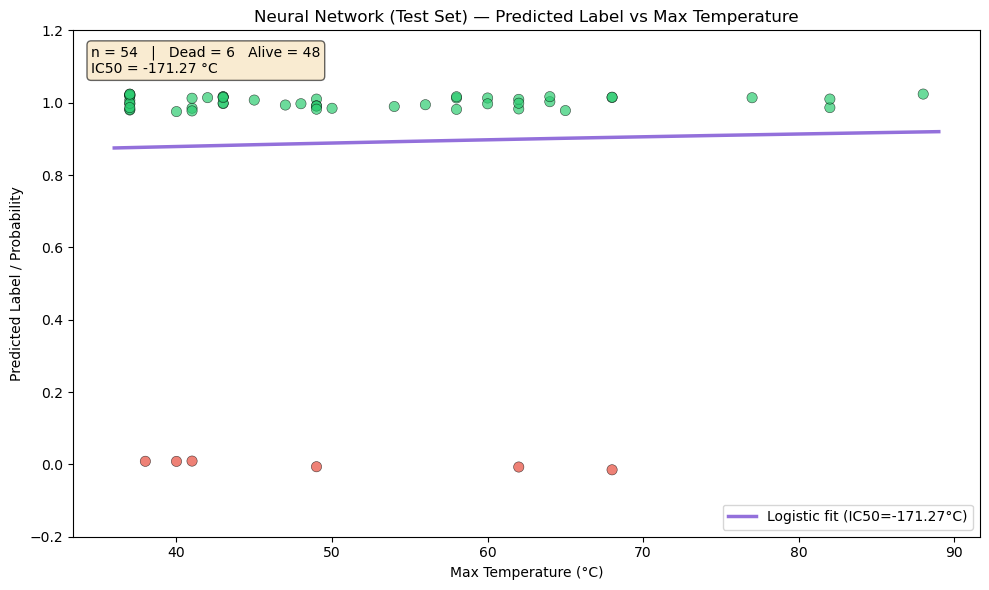

NN IC50 = -171.27 °C


In [ ]:
if max_temp_col:
    nn_test_max_temp = df_complete.iloc[_test_pos][max_temp_col].values.astype(float)
    fig_nn_t, _, ic50_nn = plot_temp_vs_predicted(
        nn_test_max_temp, nn_pred,
        title='Neural Network (Test Set) — Predicted Label vs Max Temperature',
        color='mediumpurple',
    )
    plt.show()
    print(f"NN IC50 = {ic50_nn:.2f} °C" if ic50_nn else "IC50 outside data range")
else:
    print("Max temp column not found — skipping.")


## 16. Violin Plot — Max Temperature by Predicted / True Label
Uses out-of-fold (OOF) predictions so every sample was only ever predicted
when it was held out — no training leakage.

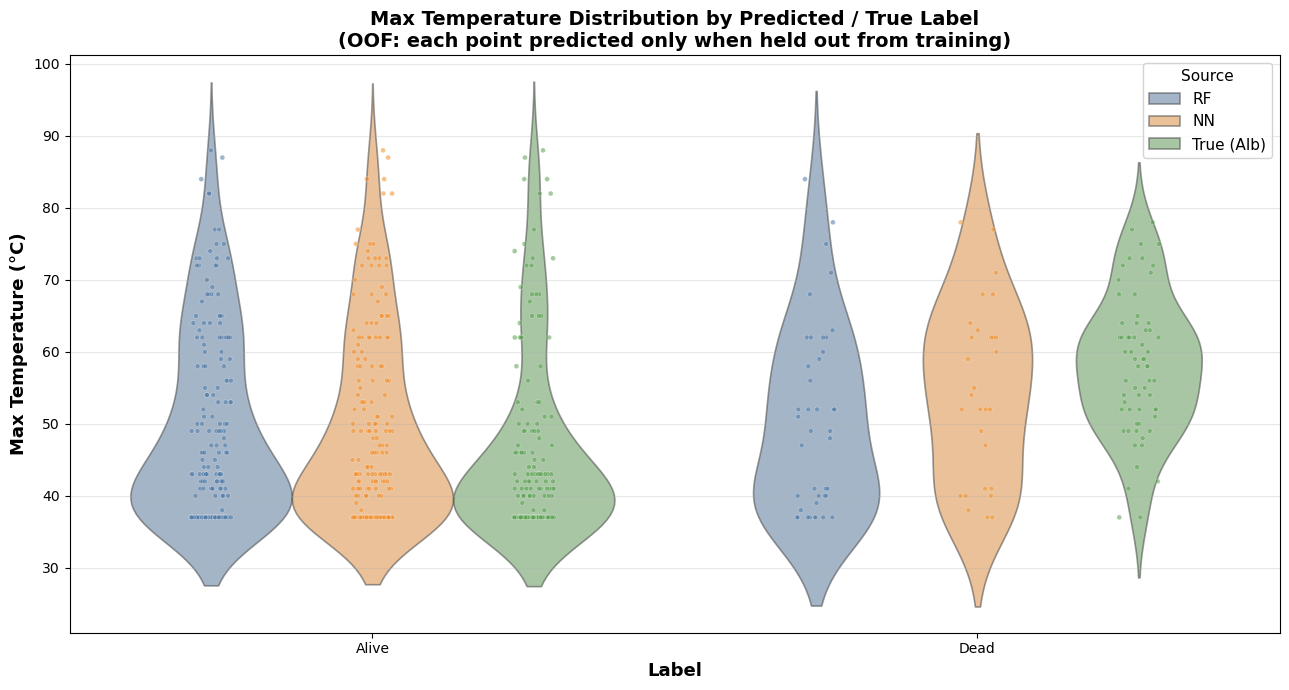

Saved → F:\Experiments\PTT\Spheroids\all data\pdx\violin_temperature_labels.png


In [ ]:
rf_label_all = pd.Series(rf_oof_pred, index=df_complete.index).map({1.0:'Alive', 0.0:'Dead'})
nn_label_all = pd.Series(nn_oof_pred, index=df_complete.index).map({1.0:'Alive', 0.0:'Dead'})

norm_alb_candidates = [c for c in df_complete.columns
                        if 'Normalised alb' in c or 'Normalised Alb' in c]

if not norm_alb_candidates:
    print("WARNING: 'Normalised alb' column not found — skipping violin plot.")
elif not max_temp_col:
    print("WARNING: Max temp column not found — skipping violin plot.")
else:
    norm_alb_col  = norm_alb_candidates[0]
    true_label_alb = (df_complete[norm_alb_col] > 50).map({True:'Alive', False:'Dead'})
    temp_all = df_complete[max_temp_col].values.astype(float)

    rows_v = []
    for rf_l, nn_l, tr_l, tmp in zip(rf_label_all, nn_label_all, true_label_alb, temp_all):
        if not np.isnan(tmp):
            rows_v += [
                {'Source':'RF',          'Label':rf_l, 'Temperature':tmp},
                {'Source':'NN',          'Label':nn_l, 'Temperature':tmp},
                {'Source':'True (Alb)',  'Label':tr_l, 'Temperature':tmp},
            ]
    violin_df = pd.DataFrame(rows_v)

    palette_v   = {'RF':'#4e79a7','NN':'#f28e2b','True (Alb)':'#59a14f'}
    hue_order_v = ['RF','NN','True (Alb)']

    fig_vio, ax_vio = plt.subplots(figsize=(13, 7))
    sns.violinplot(data=violin_df, x='Label', y='Temperature', hue='Source',
                   order=['Alive','Dead'], hue_order=hue_order_v,
                   ax=ax_vio, palette=palette_v, inner=None, alpha=0.55, linewidth=1.2)
    sns.stripplot(data=violin_df, x='Label', y='Temperature', hue='Source',
                  order=['Alive','Dead'], hue_order=hue_order_v,
                  ax=ax_vio, palette=palette_v, dodge=True, jitter=True,
                  alpha=0.55, size=3.5, linewidth=0.3, edgecolor='white', legend=False)

    handles, labels_leg = ax_vio.get_legend_handles_labels()
    ax_vio.legend(handles[:3], labels_leg[:3], title='Source',
                  fontsize=11, title_fontsize=11, loc='upper right', framealpha=0.85)
    ax_vio.set_xlabel('Label', fontsize=13, fontweight='bold')
    ax_vio.set_ylabel('Max Temperature (°C)', fontsize=13, fontweight='bold')
    ax_vio.set_title(
        'Max Temperature Distribution by Predicted / True Label\n'
        '(OOF: each point predicted only when held out from training)',
        fontsize=14, fontweight='bold',
    )
    ax_vio.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    violin_path = OUTPUT_DIR / 'violin_temperature_labels.png'
    plt.savefig(violin_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"Saved → {violin_path}")


## 17. Export CSV with OOF Predictions

In [ ]:
df_export = df_complete.copy()
df_export['RF_Prediction'] = rf_label_all.values
df_export['NN_Prediction'] = nn_label_all.values

csv_path = OUTPUT_DIR / 'predictions_export.csv'
df_export.to_csv(csv_path)
print(f"Saved → {csv_path}")
print(f"Shape: {df_export.shape[0]} rows × {df_export.shape[1]} columns")
print("New columns: RF_Prediction, NN_Prediction")


Saved → F:\Experiments\PTT\Spheroids\all data\pdx\predictions_export.csv
Shape: 214 rows × 75 columns
New columns: RF_Prediction, NN_Prediction


## 18. Paper-Quality ROC Curve (RF vs NN)

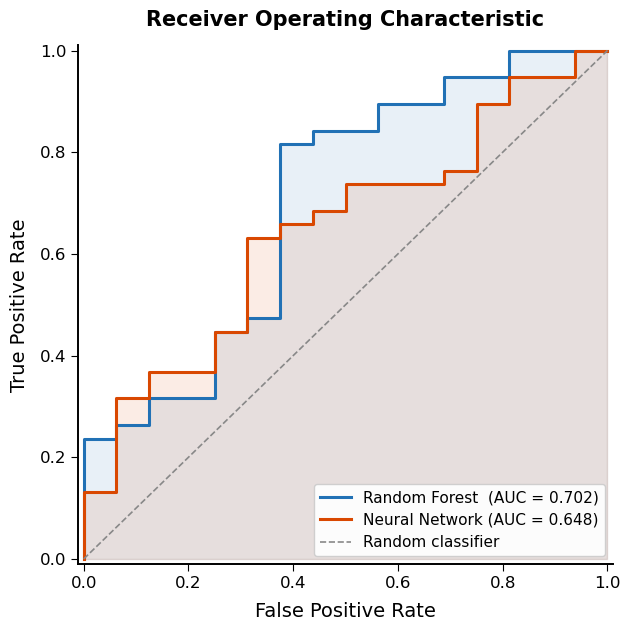

Saved → F:\Experiments\PTT\Spheroids\all data\pdx\roc_curve_rf_nn.png


In [ ]:
plt.rcParams.update({
    'font.family':'sans-serif', 'font.size':13, 'axes.linewidth':1.4,
    'axes.spines.top':False,   'axes.spines.right':False,
    'xtick.direction':'out',   'ytick.direction':'out',
    'xtick.major.size':5,      'ytick.major.size':5,
})

fpr_rf2, tpr_rf2, _ = roc_curve(y_test_final, y_proba_final)
fpr_nn2, tpr_nn2, _ = roc_curve(y_test_final, nn_proba_alive)
auc_rf2 = roc_auc_score(y_test_final, y_proba_final)
auc_nn2 = roc_auc_score(y_test_final, nn_proba_alive)

fig_roc, ax_roc = plt.subplots(figsize=(6.5, 6.5))
ax_roc.fill_between(fpr_rf2, tpr_rf2, alpha=0.10, color='#2171b5')
ax_roc.fill_between(fpr_nn2, tpr_nn2, alpha=0.10, color='#d94801')
ax_roc.plot(fpr_rf2, tpr_rf2, lw=2.2, color='#2171b5', label=f'Random Forest  (AUC = {auc_rf2:.3f})')
ax_roc.plot(fpr_nn2, tpr_nn2, lw=2.2, color='#d94801', label=f'Neural Network (AUC = {auc_nn2:.3f})')
ax_roc.plot([0,1],[0,1], lw=1.2, color='#888', linestyle='--', label='Random classifier')
ax_roc.set_xlim([-0.01,1.01]); ax_roc.set_ylim([-0.01,1.01])
ax_roc.set_xlabel('False Positive Rate', fontsize=14, labelpad=8)
ax_roc.set_ylabel('True Positive Rate',  fontsize=14, labelpad=8)
ax_roc.set_title('Receiver Operating Characteristic', fontsize=15, fontweight='bold', pad=14)
ax_roc.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax_roc.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax_roc.tick_params(labelsize=12)
ax_roc.legend(fontsize=11, frameon=True, loc='lower right', framealpha=0.92, edgecolor='#ccc')
plt.tight_layout()
roc_path = OUTPUT_DIR / 'roc_curve_rf_nn.png'
plt.savefig(roc_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
print(f"Saved → {roc_path}")
plt.rcParams.update(plt.rcParamsDefault)


## 19. Paper-Quality K-Fold Metrics Box Plots

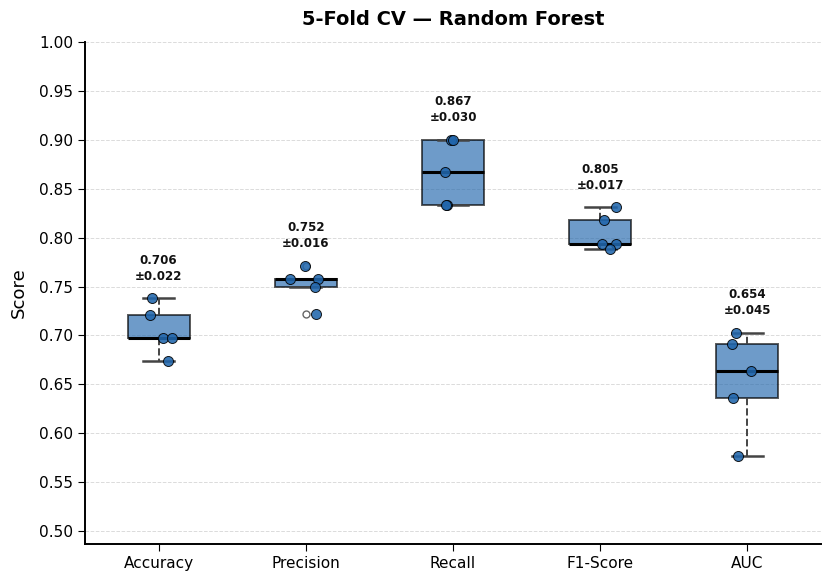

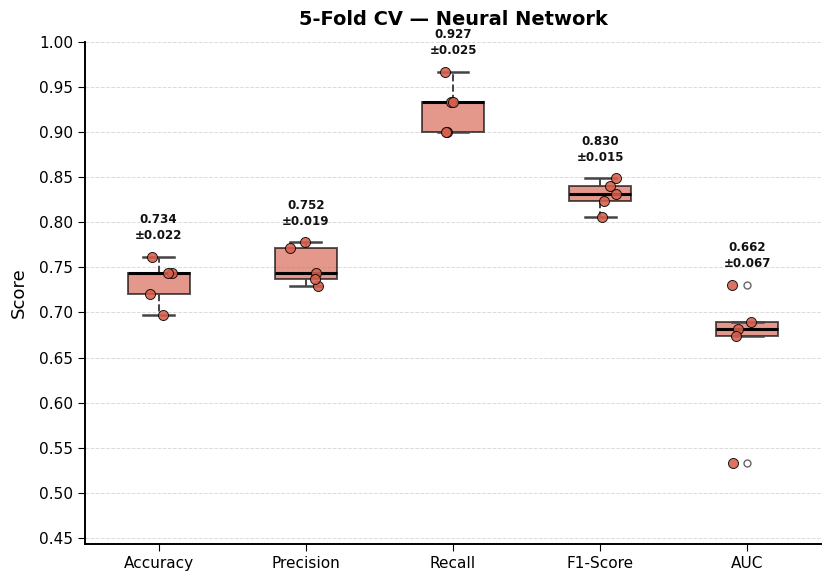

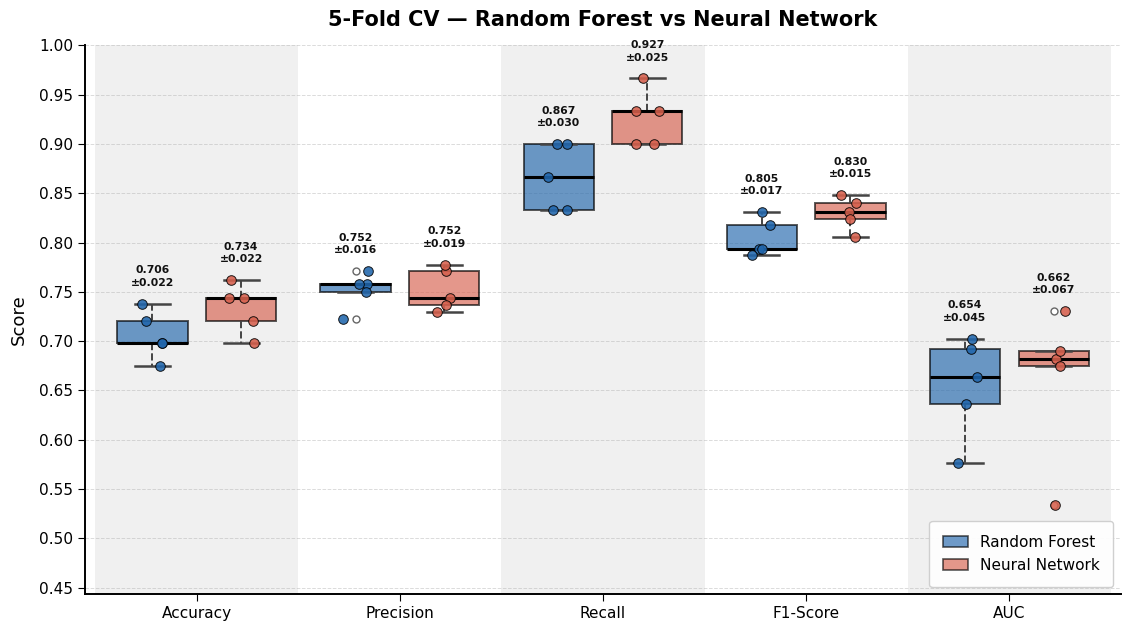

All box plots saved.


In [ ]:
plt.rcParams.update({
    'font.family':'sans-serif','font.size':13,'axes.linewidth':1.4,
    'axes.spines.top':False,'axes.spines.right':False,
    'xtick.direction':'out','ytick.direction':'out',
    'xtick.major.size':5,'ytick.major.size':5,
})

METRIC_LABELS  = ['Accuracy','Precision','Recall','F1-Score','AUC']
RF_METRIC_DATA = [fold_accuracies, fold_precisions, fold_recalls, fold_f1_scores, fold_auc_scores]
NN_METRIC_DATA = [nn_fold_accuracies, nn_fold_precisions, nn_fold_recalls,
                  nn_fold_f1_scores,  nn_fold_auc_scores]
RF_COLOR, NN_COLOR = '#2166ac', '#d6604d'

def _paper_boxplot(ax, metric_data, metric_labels, color, model_name):
    bp = ax.boxplot(
        metric_data, positions=range(len(metric_labels)), widths=0.42,
        patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2.2),
        whiskerprops=dict(color='#444', linewidth=1.4, linestyle='--'),
        capprops=dict(color='#444', linewidth=1.8),
        flierprops=dict(marker='o', markersize=5, linestyle='none',
                        markeredgecolor='#666', markerfacecolor='white', markeredgewidth=1.0),
        boxprops=dict(linewidth=1.4),
    )
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.65)

    rng = np.random.default_rng(7)
    for i, vals in enumerate(metric_data):
        jit = rng.uniform(-0.11, 0.11, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jit, vals,
                   color=color, s=52, zorder=5, edgecolors='black', linewidths=0.7, alpha=0.88)

    for i, vals in enumerate(metric_data):
        m, s = np.mean(vals), np.std(vals)
        ax.text(i, max(vals)+0.016, f'{m:.3f}\n±{s:.3f}', ha='center', va='bottom',
                fontsize=8.5, color='#111', fontweight='bold', linespacing=1.3)

    ax.set_xticks(range(len(metric_labels))); ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylabel('Score', fontsize=13, labelpad=8)
    ax.set_title(f'{n_splits}-Fold CV — {model_name}', fontsize=14, fontweight='bold', pad=12)
    all_flat = [v for vals in metric_data for v in vals]
    ax.set_ylim(max(0, min(all_flat)-0.09), min(1.0, max(all_flat)+0.13))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.tick_params(axis='both', labelsize=11, direction='out', length=5)
    ax.spines['left'].set_linewidth(1.4); ax.spines['bottom'].set_linewidth(1.4)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.45, zorder=0)

# RF
fig_rf_bp, ax_rf_bp = plt.subplots(figsize=(8.5, 6.0))
_paper_boxplot(ax_rf_bp, RF_METRIC_DATA, METRIC_LABELS, RF_COLOR, 'Random Forest')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'kfold_metrics_boxplot_RF.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()

# NN
fig_nn_bp, ax_nn_bp = plt.subplots(figsize=(8.5, 6.0))
_paper_boxplot(ax_nn_bp, NN_METRIC_DATA, METRIC_LABELS, NN_COLOR, 'Neural Network')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'kfold_metrics_boxplot_NN.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()

# Side-by-side
from matplotlib.patches import Patch as _Patch
N, GAP, OFF = len(METRIC_LABELS), 1.1, 0.24
rf_pos = [i*GAP - OFF for i in range(N)]
nn_pos = [i*GAP + OFF for i in range(N)]

fig_cmp, ax_cmp = plt.subplots(figsize=(11.5, 6.5))
rng2 = np.random.default_rng(13)

def _side_bp(ax, positions, metric_data, color, label):
    bp = ax.boxplot(metric_data, positions=positions, widths=0.38, patch_artist=True, notch=False,
                    medianprops=dict(color='black',linewidth=2.2),
                    whiskerprops=dict(color='#444',linewidth=1.4,linestyle='--'),
                    capprops=dict(color='#444',linewidth=1.8),
                    flierprops=dict(marker='o',markersize=5,linestyle='none',
                                    markeredgecolor='#666',markerfacecolor='white',markeredgewidth=1.0),
                    boxprops=dict(linewidth=1.4))
    for patch in bp['boxes']: patch.set_facecolor(color); patch.set_alpha(0.65)
    for pos, vals in zip(positions, metric_data):
        jit = rng2.uniform(-0.07,0.07,size=len(vals))
        ax.scatter(np.full(len(vals),pos)+jit, vals, color=color, s=48, zorder=5,
                   edgecolors='black', linewidths=0.7, alpha=0.88)
    for pos, vals in zip(positions, metric_data):
        m, s = np.mean(vals), np.std(vals)
        ax.text(pos, max(vals)+0.016, f'{m:.3f}\n±{s:.3f}', ha='center', va='bottom',
                fontsize=7.8, color='#111', fontweight='bold', linespacing=1.3)
    return _Patch(facecolor=color, alpha=0.65, edgecolor='black', linewidth=1.2, label=label)

p_rf = _side_bp(ax_cmp, rf_pos, RF_METRIC_DATA, RF_COLOR, 'Random Forest')
p_nn = _side_bp(ax_cmp, nn_pos, NN_METRIC_DATA, NN_COLOR, 'Neural Network')

for i in range(N):
    if i % 2 == 0:
        ax_cmp.axvspan(i*GAP - GAP/2, i*GAP + GAP/2, color='#f0f0f0', zorder=0, linewidth=0)

ax_cmp.set_xticks([i*GAP for i in range(N)]); ax_cmp.set_xticklabels(METRIC_LABELS, fontsize=12.5)
ax_cmp.set_xlim(-GAP*0.55, (N-1)*GAP + GAP*0.55)
ax_cmp.set_ylabel('Score', fontsize=13, labelpad=8)
ax_cmp.set_title(f'{n_splits}-Fold CV — Random Forest vs Neural Network', fontsize=15, fontweight='bold', pad=14)
all_flat2 = [v for md in [RF_METRIC_DATA, NN_METRIC_DATA] for vals in md for v in vals]
ax_cmp.set_ylim(max(0, min(all_flat2)-0.09), min(1.0, max(all_flat2)+0.14))
ax_cmp.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax_cmp.tick_params(axis='both', labelsize=11, direction='out', length=5)
ax_cmp.spines['left'].set_linewidth(1.4); ax_cmp.spines['bottom'].set_linewidth(1.4)
ax_cmp.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.45, zorder=0)
ax_cmp.legend(handles=[p_rf, p_nn], fontsize=11, frameon=True, loc='lower right',
              framealpha=0.92, edgecolor='#ccc', borderpad=0.9, handlelength=1.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'kfold_metrics_boxplot_RF_vs_NN.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
plt.rcParams.update(plt.rcParamsDefault)
print("All box plots saved.")


## 20. All Training Features vs Max Temperature
Each panel shows one selected feature (Y axis) against max treatment temperature (X axis).
Points are coloured by true label (green = Alive, red = Dead).
The right axis shows P(Alive) from a logistic regression fitted to temperature.
The dashed orange line marks the IC50.

Saved → F:\Experiments\PTT\Spheroids\all data\pdx\features_vs_temperature.png  (12 features, 3×5 grid)


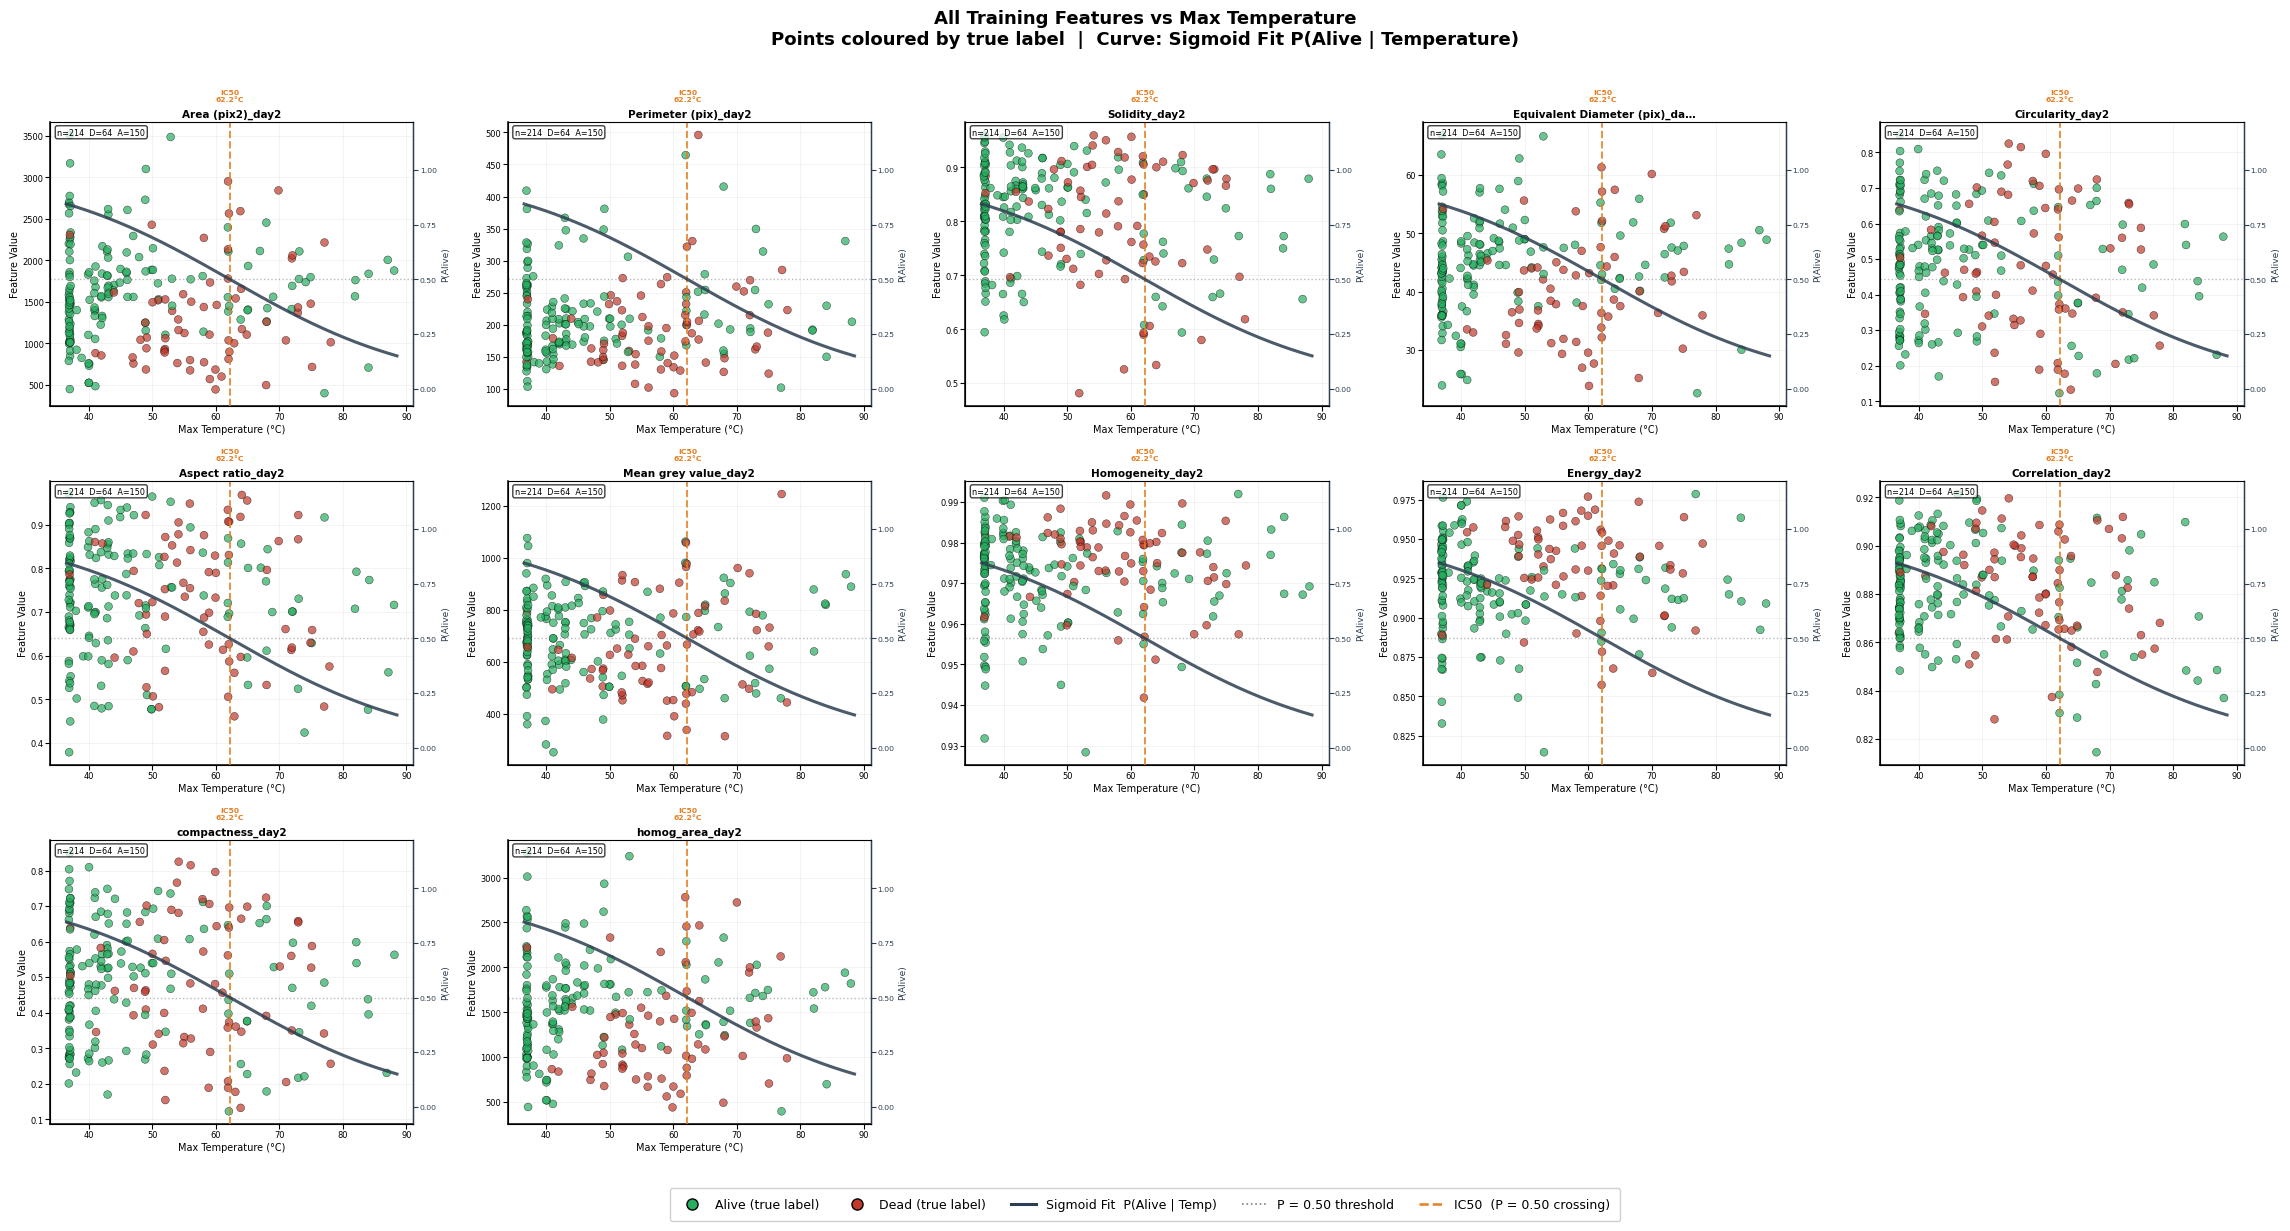

In [ ]:
if max_temp_col is None:
    print("Max temp column not found — skipping.")
else:
    from matplotlib.lines import Line2D as _Line2D

    _ALIVE_C, _DEAD_C, _LR_C, _IC50_C = '#27ae60', '#c0392b', '#2c3e50', '#e67e22'

    _temp_all  = df_complete[max_temp_col].values.astype(float)
    _y_all     = y.values
    _feat_vals = X_features[selected_feature_names].values

    _valid  = ~np.isnan(_temp_all)
    _t_v    = _temp_all[_valid]
    _y_v    = _y_all[_valid]
    _f_v    = _feat_vals[_valid]

    _N_FEAT = len(selected_feature_names)
    _N_COLS = 5
    _N_ROWS = int(np.ceil(_N_FEAT / _N_COLS))

    _fig_ft, _axes_ft = plt.subplots(_N_ROWS, _N_COLS,
                                      figsize=(_N_COLS*4.6, _N_ROWS*4.0),
                                      constrained_layout=False)
    _axes_ft = _axes_ft.flatten()
    _rng_j   = np.random.default_rng(42)

    for _fi, _fname in enumerate(selected_feature_names):
        _ax  = _axes_ft[_fi]
        _fv  = _f_v[:, _fi].astype(float)
        _fm  = ~np.isnan(_fv)
        _t   = _t_v[_fm]; _f = _fv[_fm]; _lb = _y_v[_fm]

        if len(_t) < 4:
            _ax.set_visible(False); continue

        _c_pts  = [_ALIVE_C if l == 1 else _DEAD_C for l in _lb]
        _jit_t  = _rng_j.uniform(-0.15, 0.15, size=len(_t))
        _ax.scatter(_t + _jit_t, _f, c=_c_pts, alpha=0.70, s=32,
                    edgecolors='black', linewidths=0.35, zorder=3)

        _ax2 = _ax.twinx()
        if len(np.unique(_lb)) >= 2:
            from scipy.optimize import curve_fit

            def _sigmoid(x, a, b):
                return 1.0 / (1.0 + np.exp(-(a * x + b)))

            try:
                popt, _ = curve_fit(_sigmoid, _t, _lb, p0=[0.5, -0.5 * np.median(_t)], maxfev=20000)
                _t_lin = np.linspace(_t.min() - 0.5, _t.max() + 0.5, 500)
                _p_alive = _sigmoid(_t_lin, *popt)
                _ic50_ft = -popt[1] / popt[0] if abs(popt[0]) > 1e-9 else None

                _ax2.plot(_t_lin, _p_alive, color=_LR_C, linewidth=2.2, zorder=4, alpha=0.85)
                _ax2.axhline(0.5, color='grey', linestyle=':', linewidth=1.0, alpha=0.55)
                if _ic50_ft is not None and _t.min() <= _ic50_ft <= _t.max():
                    _ax2.axvline(_ic50_ft, color=_IC50_C, linestyle='--', linewidth=1.4, alpha=0.85, zorder=2)
                    _ax2.text(_ic50_ft, 1.07, f'IC50\n{_ic50_ft:.1f}°C', ha='center', va='bottom',
                              fontsize=5.5, color=_IC50_C, fontweight='bold',
                              transform=_ax2.get_xaxis_transform())
            except Exception:
                pass

        _ax2.set_ylim(-0.08, 1.22)
        _ax2.set_ylabel('P(Alive)', fontsize=6.5, color=_LR_C, labelpad=3)
        _ax2.tick_params(axis='y', labelsize=5.5, colors=_LR_C, pad=1)
        _ax2.spines['right'].set_color(_LR_C); _ax2.spines['right'].set_linewidth(1.0)
        _ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.25))

        _short = (_fname[:28]+'…') if len(_fname) > 29 else _fname
        _ax.set_title(_short, fontsize=7.5, fontweight='bold', pad=4)
        _ax.set_xlabel('Max Temperature (°C)', fontsize=7, labelpad=2)
        _ax.set_ylabel('Feature Value',        fontsize=7, labelpad=2)
        _ax.tick_params(axis='both', labelsize=6, pad=1)
        _ax.spines['top'].set_visible(False)
        _ax.spines['left'].set_linewidth(1.1); _ax.spines['bottom'].set_linewidth(1.1)
        _ax.grid(True, alpha=0.20, linewidth=0.5, zorder=0)
        _n_d = int((_lb==0).sum()); _n_a = int((_lb==1).sum())
        _ax.text(0.02, 0.98, f'n={len(_t)}  D={_n_d}  A={_n_a}',
                 transform=_ax.transAxes, fontsize=5.8, va='top',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75))

    for _fi in range(_N_FEAT, len(_axes_ft)):
        _axes_ft[_fi].set_visible(False)

    _legend_els = [
        _Line2D([0],[0], marker='o', color='w', markerfacecolor=_ALIVE_C,
                markeredgecolor='black', markersize=8, label='Alive (true label)'),
        _Line2D([0],[0], marker='o', color='w', markerfacecolor=_DEAD_C,
                markeredgecolor='black', markersize=8, label='Dead (true label)'),
        _Line2D([0],[0], color=_LR_C, linewidth=2.2,
                label='Sigmoid Fit  P(Alive | Temp)'),
        _Line2D([0],[0], color='grey', linewidth=1.2, linestyle=':',
                label='P = 0.50 threshold'),
        _Line2D([0],[0], color=_IC50_C, linewidth=1.8, linestyle='--',
                label='IC50  (P = 0.50 crossing)'),
    ]
    _fig_ft.legend(handles=_legend_els, loc='lower center', ncol=5, fontsize=9,
                   frameon=True, framealpha=0.92, edgecolor='#ccc', borderpad=0.8,
                   bbox_to_anchor=(0.5, -0.005))
    _fig_ft.suptitle(
        'All Training Features vs Max Temperature\n'
        'Points coloured by true label  |  Curve: Sigmoid Fit P(Alive | Temperature)',
        fontsize=13, fontweight='bold', y=1.01,
    )

    plt.tight_layout(rect=[0, 0.045, 1, 1])

    feat_temp_path = OUTPUT_DIR / 'features_vs_temperature.png'
    print(f"Saved → {feat_temp_path}  ({_N_FEAT} features, {_N_ROWS}×{_N_COLS} grid)")

    plt.savefig(feat_temp_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close()

## 21. Final Summary

In [ ]:
ic50_rf_str = f"{ic50_rf:.2f} °C"  if 'ic50_rf' in dir() and ic50_rf  else "outside range"
ic50_nn_str = f"{ic50_nn:.2f} °C"  if 'ic50_nn' in dir() and ic50_nn  else "outside range"
ic50_bf_str = f"{ic50_bf:.2f} °C"  if 'ic50_bf' in dir() and ic50_bf  else "outside range"

print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nRandom Forest (5-fold CV):")
print(f"  Accuracy  : {np.mean(fold_accuracies)*100:.1f}% ± {np.std(fold_accuracies)*100:.1f}%")
print(f"  F1-Score  : {np.mean(fold_f1_scores):.3f} ± {np.std(fold_f1_scores):.3f}")
print(f"  AUC       : {np.mean(fold_auc_scores):.3f} ± {np.std(fold_auc_scores):.3f}")
print(f"\nRF Test Set:  Acc={final_acc:.3f}  F1={final_f1:.3f}  AUC={final_auc:.3f}")
print(f"NN Test Set:  Acc={nn_acc:.3f}  F1={nn_f1:.3f}  AUC={nn_auc:.3f}")
print(f"\nIC50 estimates (Temperature at P(Alive)=0.50):")
print(f"  RF best fold : {ic50_bf_str}")
print(f"  RF test set  : {ic50_rf_str}")
print(f"  NN test set  : {ic50_nn_str}")
print(f"\nOutputs written to: {OUTPUT_DIR}")


ANALYSIS COMPLETE

Random Forest (5-fold CV):
  Accuracy  : 70.6% ± 2.2%
  F1-Score  : 0.805 ± 0.017
  AUC       : 0.654 ± 0.045

RF Test Set:  Acc=0.722  F1=0.810  AUC=0.702
NN Test Set:  Acc=0.704  F1=0.814  AUC=0.648

IC50 estimates (Temperature at P(Alive)=0.50):
  RF best fold : 93.92 °C
  RF test set  : -226.69 °C
  NN test set  : -171.27 °C

Outputs written to: F:\Experiments\PTT\Spheroids\all data\pdx
